In [25]:
import sys
import logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
from E9_fn import util
import E9_fn.E9_models as E9M
import E9_fn.thermodynamics as thmdy

In [26]:
# Helper functions
def make_offset_fn(offset, f0):
    """Generator of reservoir DoS.
    
    My old code that uses lambda functions has some reference issues."""
    def fn_out(x):
        return f0(x - offset)
    return fn_out

In [27]:
# Load the pre-calculated orbital energies, and get some basic values from it
V = 3 * 500**2      # size of the experiment (imagine a kagome lattice with n*n unit cells)
bandwidth = 6       # bandwidth (of band structure; 6 for tight-binding kagome lattice)

# System
sys_name = "system"
r_s = 0.5           # ratio of the system size
fhbw = 0.0         # half band width of the flat band used in DoS, if not added as degenerate states
E_range_s = (0, bandwidth + fhbw)  # energies considered in calculation
DoS_sys = lambda x: util.kagome_DoS(x, hbw = bandwidth / 2, fhbw = fhbw) # Density of states

# Reservoirs
res_name = "reservoir"
offset = -4.5       # energy offsets in the DoS of reservoir

# Whole experiment
sp_name = "fermi1"

### Derived variables ###
# These parameters are used in default muVT systems, but may be overwritten if something
# is being scanned (offset, r_s etc.)
V_s = int(V * r_s)              # size of the system
V_rsv = int(V - V_s)            # size of the reservoir
rsv_rel_size = 1 / r_s - 1      # relative size of the reservoir, also = V_rsv / V_s

E_range_rsv = (offset, offset + bandwidth + fhbw)
DoS_rsv = make_offset_fn(offset, DoS_sys)

dgn_list_s, dgn_list_rsv = [], []
if fhbw == 0.: # actually set E = bandwidth for all the flat band states
    dgn_list_s = [(bandwidth, int(V_s / 3.))]
    dgn_list_rsv = [(bandwidth + offset, int(V_rsv / 3.))]
sr_list = [E9M.muVT_subregion(sys_name, sp_name, V_s, +1, DoS_sys, E_range_s, dgn_list_s, None),
           E9M.muVT_subregion(res_name, sp_name, V_rsv, +1, DoS_rsv, E_range_rsv, dgn_list_rsv, None)]
E_orbs_s = thmdy.E_orbs_with_deg(DoS_sys, E_range_s, V_s - int(V_s / 3.), dgn_list = dgn_list_s)
E_orbs_rsv = thmdy.E_orbs_with_deg(DoS_rsv, E_range_rsv, V_rsv - int(V_rsv / 3.), dgn_list = dgn_list_rsv)

In [ ]:
#%% Calculation
mu_scan = np.linspace(1, 2, 51)
T_scan = np.linspace(0.01, 0.5, 50)
# T_scan = np.linspace(0.001, 0.009, 9)
exp_list = [[None for _ in mu_scan] for _ in T_scan]
s_list = np.zeros_like(exp_list, dtype = float)
s_S_list = np.zeros_like(exp_list, dtype = float)
s_R_list = np.zeros_like(exp_list, dtype = float)
N_list = np.zeros_like(exp_list, dtype = float)
nu_s_list = np.zeros_like(exp_list, dtype = float)
nu_rsv_list = np.zeros_like(exp_list, dtype = float)
for i, T in enumerate(T_scan):
    print(f"T = {T}")
    for j, mu in enumerate(mu_scan):
        exp_ij = E9M.muVT_exp(T, sr_list, {sp_name: mu})
        exp_list[i][j] = exp_ij
        s_list[i, j] = exp_ij.S / V
        s_S_list[i, j] = exp_ij.results["system"]["S"] / V_s
        s_R_list[i, j] = exp_ij.results["reservoir"]["S"] / V_rsv
        N_list[i, j] = exp_ij.N_dict[sp_name]
        nu_s_list[i, j] = sum(util.fermi_stat(E_orbs_s, T, mu)) / V_s
        nu_rsv_list[i, j] = sum(util.fermi_stat(E_orbs_rsv, T, mu)) / V_rsv

n_list = N_list / V
# assert np.allclose(n_list, nu_s_list + nu_rsv_list)

T = 0.01
T = 0.02
T = 0.03
T = 0.04
T = 0.05
T = 0.060000000000000005
T = 0.06999999999999999
T = 0.08
T = 0.09
T = 0.09999999999999999
T = 0.11
T = 0.12
T = 0.13
T = 0.14
T = 0.15000000000000002
T = 0.16
T = 0.17
T = 0.18000000000000002
T = 0.19
T = 0.2
T = 0.21000000000000002
T = 0.22
T = 0.23
T = 0.24000000000000002
T = 0.25
T = 0.26
T = 0.27
T = 0.28
T = 0.29000000000000004
T = 0.3
T = 0.31
T = 0.32
T = 0.33
T = 0.34
T = 0.35000000000000003
T = 0.36000000000000004
T = 0.37
T = 0.38
T = 0.39
T = 0.4
T = 0.41000000000000003
T = 0.42000000000000004
T = 0.43
T = 0.44
T = 0.45
T = 0.46
T = 0.47000000000000003
T = 0.48000000000000004
T = 0.49
T = 0.5


AssertionError: 

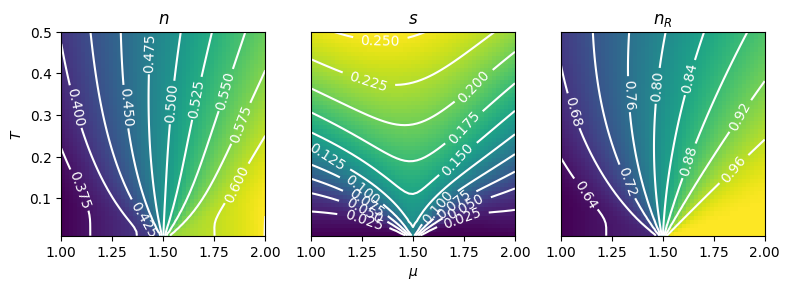

In [34]:
fig, axes = plt.subplots(1, 3, figsize = (8, 3))
n_cntr = 10
for ttl, data, ax in zip([r"$n$", r"$s$", r"$n_R$"],
                         [n_list, s_list, nu_rsv_list],
                         axes):
    img = ax.imshow(data, aspect = (mu_scan[-1] - mu_scan[0]) / (T_scan[-1] - T_scan[0]),
              extent = [mu_scan[0], mu_scan[-1], T_scan[0], T_scan[-1]], origin = "lower")
    ax.set_title(ttl)
    cntr = ax.contour(mu_scan, T_scan, data, colors = "white", levels = n_cntr)
    ax.clabel(cntr, inline = True)
    # plt.colorbar(mappable = img, ax = ax)
axes[1].set_xlabel(r"$\mu$")
axes[0].set_ylabel(r"$T$")
axes[1].set_yticks([])
axes[2].set_yticks([])
fig.tight_layout()

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\flatband")
file_full_path = Path(thesis_fig_path, "kag_thmdy_EoS_Vrsv-4.5.pdf")
# fig.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches='tight')

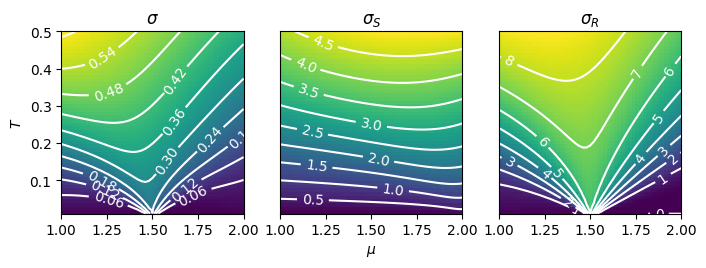

In [ ]:
fig2, axes2 = plt.subplots(1, 3, figsize = (8, 3))
n_cntr = 10
for ttl, data, ax in zip([r"$\sigma$", r"$\sigma_S$", r"$\sigma_R$"],
                         [s_list / n_list, s_S_list / V_s, s_R_list / V_rsv],
                         axes2):
    img = ax.imshow(data, aspect = (mu_scan[-1] - mu_scan[0]) / (T_scan[-1] - T_scan[0]),
              extent = [mu_scan[0], mu_scan[-1], T_scan[0], T_scan[-1]], origin = "lower")
    ax.set_title(ttl)
    cntr = ax.contour(mu_scan, T_scan, data, colors = "white", levels = n_cntr)
    ax.clabel(cntr, inline = True)
    # plt.colorbar(mappable = img, ax = ax)
axes2[1].set_xlabel(r"$\mu$")
axes2[0].set_ylabel(r"$T$")
axes2[1].set_yticks([])
axes2[2].set_yticks([])
fig.tight_layout()

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\flatband")
file_full_path = Path(thesis_fig_path, "kag_thmdy_sigmas_Vrsv-4.5.pdf")
# fig2.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches='tight')